# Notebook 06 — Full Signal Efficacy: What Happens to Prices Around Every Alert

**The desk's question, answered with full data:** after a STARTING alert,
how much did prices move over the next 3 / 10 / 21 / 84 days? After an
ENDING alert, how much did they fall? What is the hit rate, what would a
simple overlay have earned, and where does the signal work name by name?

**Honesty note, stated before any number (this matters at a defense):**
notebook 04 ran the *pre-registered, confirmatory* trading test — one
horizon (the frozen 20d HOLD_DAYS), criterion written before results —
and REJECTED both trading claims. THIS notebook is the *descriptive*
efficacy report at the desk-requested horizons (3 / 10 / 21 / 84 days:
21 = the alert cooldown, 84 = the project's BASELINE window, 3 and 10 =
desk-requested short looks). Four horizons × two signals = eight looks
at the same alerts, so read PATTERNS across horizons, not any single
starred number — the confirmatory verdict remains notebook 04's.

Alerts are the tournament winners' walk-forward alerts (out-of-sample,
identical to notebooks 03/04). Every alert, every instrument, full data.

In [22]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
HORIZONS = [3, 10, 21, 84]        # desk-requested; 21 = cooldown, 84 = BASELINE

## Reproduce the winners' out-of-sample alerts (identical to NB04)

In [23]:
from analytics.euphoria import build_all_series
from analytics.euphoria_phases import (build_day_frame, run_tournament_entry,
                                       ONSET_BANK)
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK
from analytics.loaders import load, THEME_COUNTS, THEME_SENT, \
    TICKER_COUNTS, TICKER_SENT

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)
FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]
onset_frame = frame[frame.hype_raw >= 1].copy()
top_frame = frame[frame.hype_ok].copy()

def rules_onset(train, apply, feats):
    return apply[feats].mean(axis=1).values

def rules_top(train, apply, feats):
    sc = apply[feats].mean(axis=1).values
    return np.where((apply["e1"] >= 0.90) & (apply["e2"] > 0), sc, 0.0)

ow = run_tournament_entry(onset_frame, episodes, ONSET_BANK, "y_onset",
                          "onset", rules_onset, FA_BUDGET)
tw = run_tournament_entry(top_frame, episodes, TOP_BANK, "y_top",
                          "top", rules_top, FA_BUDGET)
sym_by = {es.name: es.symbol for es in series}
kind_by = {es.name: es.kind for es in series}
pxd = {s_: p.dropna().asfreq("D").ffill() for s_, p in pxmap.items()}
print(f"{time.time()-t0:.0f}s | onset alerts: "
      f"{sum(len(v) for v in ow['alerts_by_name'].values())} | top alerts: "
      f"{sum(len(v) for v in tw['alerts_by_name'].values())}")

83s | onset alerts: 215 | top alerts: 67


## Every alert with its forward returns — the full table

In [24]:
def fwd_ret(name, d, h):
    px = pxd.get(sym_by[name])
    if px is None or d not in px.index:
        return np.nan
    fut = px.loc[d:d + pd.Timedelta(days=h)]
    if len(fut) < 2 or (fut.index[-1] - d).days < h * 0.6:
        return np.nan                    # not enough future price yet
    return float(fut.iloc[-1] / fut.iloc[0] - 1)

def alert_table(entry, signal):
    rows = []
    for name, alerts in entry["alerts_by_name"].items():
        for d in alerts:
            r = {"name": name, "kind": kind_by[name],
                 "symbol": sym_by[name], "signal": signal, "date": d}
            for h in HORIZONS:
                r[f"fwd_{h}d"] = fwd_ret(name, d, h)
            rows.append(r)
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

alerts_all = pd.concat([alert_table(ow, "START"),
                        alert_table(tw, "END")], ignore_index=True)
pd.set_option("display.max_rows", 400)
print("EVERY alert, THEMES (full data):")
display(alerts_all[alerts_all.kind == "theme"]
        .drop(columns=["kind"]).round(3))
print("EVERY alert, SINGLE NAMES (full data):")
display(alerts_all[alerts_all.kind == "single"]
        .drop(columns=["kind"]).round(3))

EVERY alert, THEMES (full data):


,name,symbol,signal,date,fwd_3d,fwd_10d,fwd_21d,fwd_84d
0,fintech_payments,XLF,START,2018-01-30,-0.010,-0.067,-0.026,-0.067
1,consumer_retail,XLY,START,2018-01-31,-0.021,-0.065,-0.032,-0.054
2,shipping_logistics,IYT,START,2018-02-01,-0.021,-0.071,-0.042,-0.045
3,memory,SMH,START,2018-02-01,-0.028,-0.077,-0.024,-0.067
4,fintech_payments,XLF,START,2018-03-11,-0.026,-0.033,-0.072,-0.075
5,biotech_pharma,XBI,START,2018-03-14,-0.020,-0.072,-0.087,0.024
6,gaming_esports,SOCL,START,2018-03-31,-0.034,-0.014,-0.007,0.074
8,japan,1622 JT,START,2018-04-05,0.000,0.011,0.033,-0.019
9,short_squeeze,ARKK,START,2018-04-10,0.008,0.024,-0.009,0.131
10,ev_clean_energy,LIT,START,2018-04-23,-0.014,-0.009,0.020,-0.026


EVERY alert, SINGLE NAMES (full data):


,name,symbol,signal,date,fwd_3d,fwd_10d,fwd_21d,fwd_84d
7,TSLA,TSLA,START,2018-04-01,0.078,0.131,0.091,0.254
12,AMZN,AMZN,START,2018-04-27,-0.004,0.017,0.001,0.153
13,NVDA,NVDA,START,2018-05-14,-0.030,-0.030,0.037,-0.005
17,MSFT,MSFT,START,2018-07-21,0.013,-0.002,0.026,0.031
20,SNAP,SNAP,START,2018-08-07,-0.062,-0.094,-0.139,-0.510
36,NFLX,NFLX,START,2019-01-17,-0.040,-0.043,-0.024,0.041
68,TSLA,TSLA,START,2019-12-23,0.028,0.026,0.252,0.062
72,AMZN,AMZN,START,2020-01-31,-0.002,0.062,0.043,0.200
80,SPY,SPY,START,2020-03-16,0.003,0.089,0.104,0.348
82,SNAP,SNAP,START,2020-04-27,0.041,0.073,0.034,0.494


## Headline: mean move, hit rate, and the baseline it must beat

The baseline is the same-instrument unconditional forward return over
every candidate day (the days the detector was allowed to speak) — the
honest "what if you acted on a random eligible day" comparison. Hit
rate = share of alerts followed by the EXPECTED direction (up after
START, down after END). The baseline hit rate is what a coin weighted
by the market's drift would score — markets drift up, so ~50% down-hits
after END is *better than it looks*; always compare to the baseline
column, not to 50%.

In [25]:
def baseline_rets(names, h):
    rows = []
    for name in set(names):
        days = frame.loc[frame.name == name, "date"]
        px = pxd.get(sym_by[name])
        if px is None:
            continue
        fut = px.shift(-h)
        rr = (fut / px - 1).reindex(days).dropna()
        rows.append(pd.DataFrame({"name": name, "fwd": rr.values}))
    return (pd.concat(rows, ignore_index=True) if rows
            else pd.DataFrame(columns=["name", "fwd"]))

def cluster_ci(adf, bdf, col, n_boot=300, seed=42):
    names = sorted(set(adf.name))
    a_by = {n: g[col].dropna().values for n, g in adf.groupby("name")}
    b_by = {n: g["fwd"].values for n, g in bdf.groupby("name")}
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        pick = rng.choice(names, size=len(names), replace=True)
        a = np.concatenate([a_by[n] for n in pick if len(a_by.get(n, []))])
        b = np.concatenate([b_by[n] for n in pick if n in b_by])
        if len(a) and len(b):
            diffs.append(a.mean() - b.mean())
    return float(np.percentile(diffs, 5)), float(np.percentile(diffs, 95))

summary_rows = []
for signal, direction in (("START", +1), ("END", -1)):
    sub = alerts_all[alerts_all.signal == signal]
    for h in HORIZONS:
        col = f"fwd_{h}d"
        vals = sub[col].dropna()
        base = baseline_rets(sub.name, h)
        lo_, hi_ = cluster_ci(sub, base, col)
        hit = ((vals > 0) if direction > 0 else (vals < 0)).mean()
        bhit = ((base.fwd > 0) if direction > 0
                else (base.fwd < 0)).mean()
        summary_rows.append({
            "signal": signal, "horizon_d": h, "n": len(vals),
            "mean_move": round(vals.mean(), 4),
            "median_move": round(vals.median(), 4),
            "hit_rate": round(hit, 3),
            "baseline_mean": round(base.fwd.mean(), 4),
            "baseline_hit": round(bhit, 3),
            "edge_vs_baseline": round(vals.mean() - base.fwd.mean(), 4),
            "edge_ci90": f"[{lo_:+.3f}, {hi_:+.3f}]",
            "ci_excludes_0": bool(lo_ > 0 if direction > 0 else hi_ < 0),
        })
summary = pd.DataFrame(summary_rows)
summary

,signal,horizon_d,n,mean_move,median_move,hit_rate,baseline_mean,baseline_hit,edge_vs_baseline,edge_ci90,ci_excludes_0
0,START,3,215,0.0082,0.0000,0.465,0.0015,0.517,0.0067,"[-0.001, +0.019]",False
1,START,10,215,0.0384,0.0009,0.521,0.0047,0.548,0.0337,"[-0.004, +0.110]",False
2,START,21,215,0.0022,0.0076,0.540,0.0103,0.557,-0.0081,"[-0.017, +0.002]",False
3,START,84,215,0.0192,0.0072,0.535,0.0407,0.591,-0.0216,"[-0.043, +0.000]",False
4,END,3,67,-0.0032,0.0000,0.493,0.0021,0.460,-0.0053,"[-0.015, +0.005]",False
5,END,10,67,-0.0262,-0.0222,0.567,0.0064,0.453,-0.0327,"[-0.066, -0.003]",True
6,END,21,67,0.0071,-0.0110,0.552,0.0140,0.447,-0.0069,"[-0.049, +0.039]",False
7,END,84,67,0.1214,-0.0089,0.507,0.0554,0.416,0.0660,"[-0.064, +0.263]",False


## Event study — the average price path around each signal

Mean cumulative return from 21 days before to 84 days after every
alert, indexed to the alert day. If the signals mean anything, the
START path should keep climbing after the flag and the END path should
roll over.

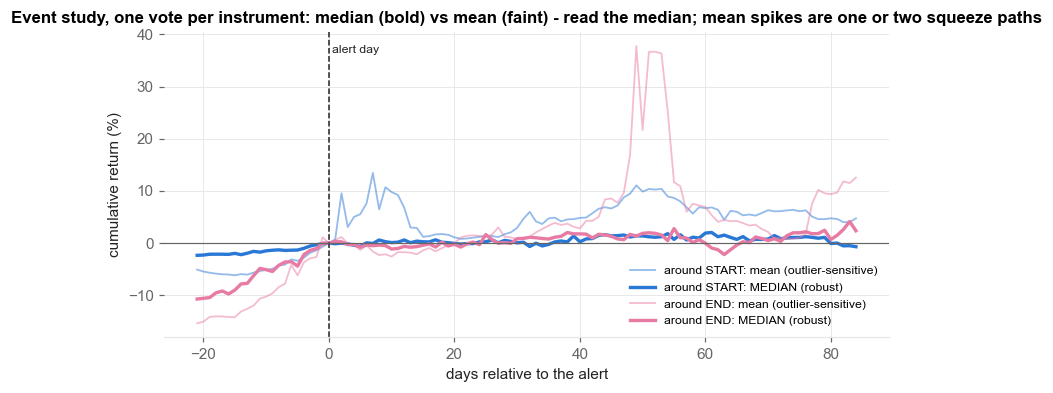

In [26]:
def event_paths(entry, lo_d=-21, hi_d=84):
    """Per-INSTRUMENT paths first (a name that alerted ten times gets one
    vote, not ten - meme names must not dominate the average), then the
    cross-instrument mean AND median. The median is outlier-immune: a
    single post-alert short squeeze can drag a 67-path mean up 30 points
    for a few days (a sharp up-down spike is the fingerprint of one or
    two paths, never of a real market effect, which would be smooth)."""
    by_name = {}
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd.get(sym_by[name])
        if px is None:
            continue
        for d in alerts:
            win = px.loc[d + pd.Timedelta(days=lo_d):
                         d + pd.Timedelta(days=hi_d)]
            if d not in win.index or len(win) < 40:
                continue
            rel = (win / win.loc[d] - 1) * 100
            rel.index = (rel.index - d).days
            by_name.setdefault(name, []).append(rel)
    if not by_name:
        return None, None
    per_name = []
    for name, paths in by_name.items():
        stacked = pd.concat(paths, axis=1)
        stacked = stacked.groupby(stacked.index).mean()
        per_name.append(stacked.mean(axis=1))
    allp = pd.concat(per_name, axis=1)
    allp = allp.groupby(allp.index).mean()
    return allp.mean(axis=1), allp.median(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for entry, lbl, c in ((ow, "START", C1), (tw, "END", C3)):
    mean_p, med_p = event_paths(entry)
    if mean_p is None:
        continue
    ax.plot(mean_p.index, mean_p.values, color=c, lw=1.2, alpha=0.5,
            label=f"around {lbl}: mean (outlier-sensitive)")
    ax.plot(med_p.index, med_p.values, color=c, lw=2.2,
            label=f"around {lbl}: MEDIAN (robust)")
ax.axvline(0, color=INK, lw=1, ls="--")
ax.text(0.5, ax.get_ylim()[1] * 0.9, "alert day", fontsize=8, color=INK)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel("days relative to the alert")
ax.set_ylabel("cumulative return (%)")
ax.set_title("Event study, one vote per instrument: median (bold) vs "
             "mean (faint) - read the median; mean spikes are one or two "
             "squeeze paths")
ax.legend(frameon=False, fontsize=8)
despine(ax)
plt.show()

## Is this a valid signal? — confidence intervals everywhere

Three views, all with instrument-cluster bootstrap uncertainty (the
instrument is the independent unit; daily rows within a name are not):

1. **Forest plot** — the edge over baseline per signal x horizon with
   its 90% CI. A valid signal shows CIs consistently on one side of
   zero SOMEWHERE, not stars scattered at random.
2. **Event-study with a CI band** — the average path around alerts with
   the band of paths you would get resampling instruments.
3. **Hit rates vs the drift-adjusted baseline** — with CIs, because a
   57% down-hit only means something relative to a 45% baseline.

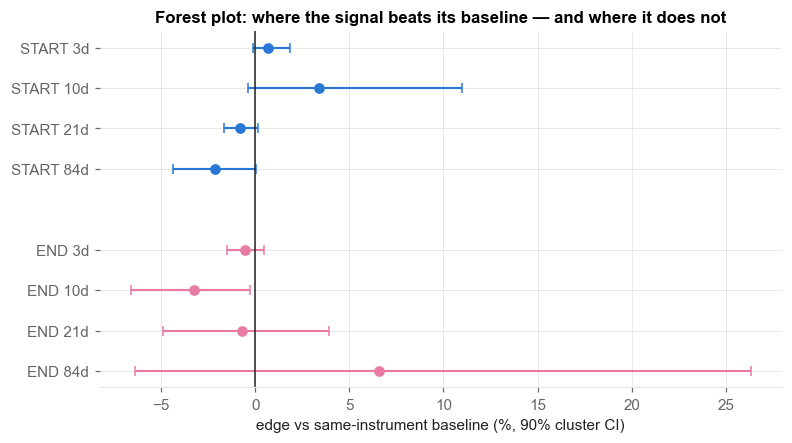

In [27]:
def cluster_boot_stat(df, col, stat, n_boot=300, seed=42):
    by = {n: g[col].dropna().values for n, g in df.groupby("name")}
    names = [n for n, v in by.items() if len(v)]
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        pick = rng.choice(names, size=len(names), replace=True)
        vals = np.concatenate([by[n] for n in pick])
        if len(vals):
            out.append(stat(vals))
    return np.percentile(out, [5, 95])

fig, ax = plt.subplots(figsize=(8, 4.2))
ypos, labels = [], []
for i, (signal, direction, c) in enumerate(
        [("START", +1, C1), ("END", -1, C3)]):
    sub = alerts_all[alerts_all.signal == signal]
    for j, h in enumerate(HORIZONS):
        col = f"fwd_{h}d"
        base = baseline_rets(sub.name, h)
        edge = sub[col].dropna().mean() - base.fwd.mean()
        lo_, hi_ = cluster_ci(sub, base, col)
        y = i * (len(HORIZONS) + 1) + j
        ax.errorbar(edge * 100, y, xerr=[[(edge - lo_) * 100],
                                         [(hi_ - edge) * 100]],
                    fmt="o", color=c, ms=6, capsize=3, lw=1.4)
        ypos.append(y)
        labels.append(f"{signal} {h}d")
ax.axvline(0, color=INK, lw=1)
ax.set_yticks(ypos, labels)
ax.invert_yaxis()
ax.set_xlabel("edge vs same-instrument baseline (%, 90% cluster CI)")
ax.set_title("Forest plot: where the signal beats its baseline — and "
             "where it does not")
despine(ax)
plt.show()

## Event study with uncertainty bands

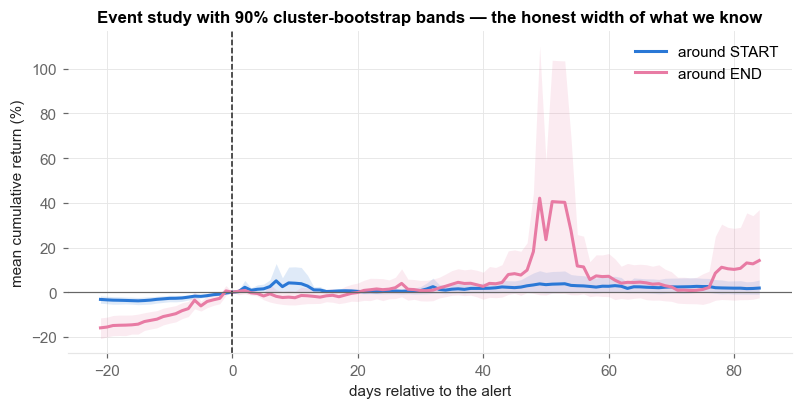

In [28]:
def event_paths_by_name(entry, lo_d=-21, hi_d=84):
    by = {}
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd.get(sym_by[name])
        if px is None:
            continue
        for d in alerts:
            win = px.loc[d + pd.Timedelta(days=lo_d):
                         d + pd.Timedelta(days=hi_d)]
            if d not in win.index or len(win) < 40:
                continue
            rel = (win / win.loc[d] - 1) * 100
            rel.index = (rel.index - d).days
            by.setdefault(name, []).append(rel)
    return by

def boot_band(by, n_boot=200, seed=42):
    names = list(by)
    rng = np.random.default_rng(seed)
    grid = np.arange(-21, 85)
    means = []
    for _ in range(n_boot):
        pick = rng.choice(names, size=len(names), replace=True)
        paths = [p for n in pick for p in by[n]]
        stacked = pd.concat(paths, axis=1)
        stacked = stacked.groupby(stacked.index).mean()
        means.append(stacked.mean(axis=1).reindex(grid).interpolate())
    m = pd.concat(means, axis=1)
    return m.mean(axis=1), m.quantile(0.05, axis=1), m.quantile(0.95, axis=1)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
for entry, lbl, c in ((ow, "around START", C1), (tw, "around END", C3)):
    by = event_paths_by_name(entry)
    if not by:
        continue
    mid, lo_b, hi_b = boot_band(by)
    ax.plot(mid.index, mid.values, color=c, lw=2, label=lbl)
    ax.fill_between(mid.index, lo_b.values, hi_b.values, color=c,
                    alpha=0.15, lw=0)
ax.axvline(0, color=INK, lw=1, ls="--")
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel("days relative to the alert")
ax.set_ylabel("mean cumulative return (%)")
ax.set_title("Event study with 90% cluster-bootstrap bands — the honest "
             "width of what we know")
ax.legend(frameon=False)
despine(ax)
plt.show()

## Hit rates vs the drift-adjusted baseline (with CIs)
and the END signal's year-by-year stability — a valid signal should not
owe its whole record to one regime.

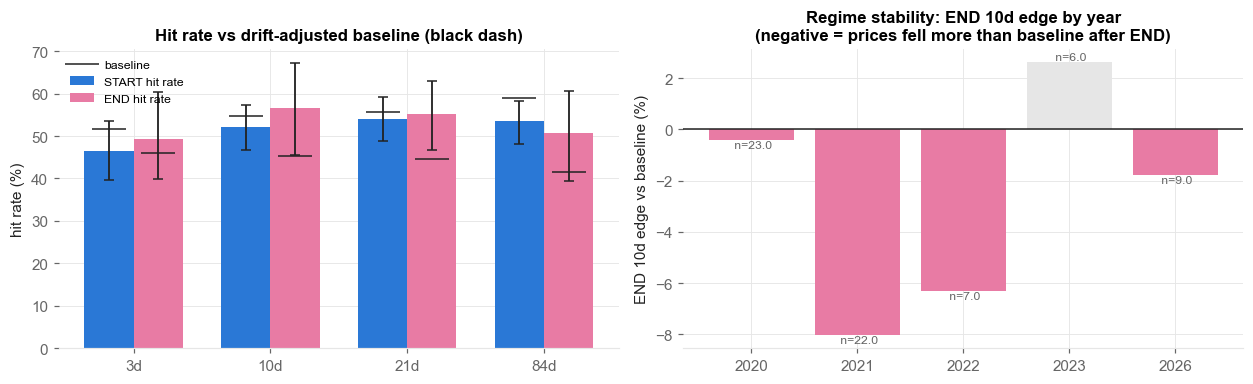

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
ax = axes[0]
x = np.arange(len(HORIZONS))
for k, (signal, direction, c, off) in enumerate(
        [("START", +1, C1, -0.18), ("END", -1, C3, +0.18)]):
    sub = alerts_all[alerts_all.signal == signal]
    hits, blo, bhi, bases = [], [], [], []
    for h in HORIZONS:
        col = f"fwd_{h}d"
        if direction > 0:
            stat = lambda v: (v > 0).mean()
        else:
            stat = lambda v: (v < 0).mean()
        hits.append(stat(sub[col].dropna().values))
        lo_, hi_ = cluster_boot_stat(sub, col, stat)
        blo.append(lo_)
        bhi.append(hi_)
        base = baseline_rets(sub.name, h)
        bases.append(stat(base.fwd.values))
    hits, blo, bhi = map(np.array, (hits, blo, bhi))
    ax.bar(x + off, hits * 100, 0.36, color=c, label=f"{signal} hit rate")
    ax.errorbar(x + off, hits * 100, yerr=[(hits - blo) * 100,
                                           (bhi - hits) * 100],
                fmt="none", ecolor=INK, capsize=3, lw=1.2)
    ax.plot(x + off, np.array(bases) * 100, "_", color=INK, ms=22,
            label="baseline" if k == 0 else None)
ax.set_xticks(x, [f"{h}d" for h in HORIZONS])
ax.set_ylabel("hit rate (%)")
ax.set_title("Hit rate vs drift-adjusted baseline (black dash)")
ax.legend(frameon=False, fontsize=8)
despine(ax)

ax = axes[1]
ends = alerts_all[alerts_all.signal == "END"].copy()
ends["year"] = ends.date.dt.year
rows = []
for y, g in ends.groupby("year"):
    vals = g["fwd_10d"].dropna()
    if len(vals) < 3:
        continue
    base = baseline_rets(g.name, 10)
    rows.append({"year": y, "edge": (vals.mean() - base.fwd.mean()) * 100,
                 "n": len(vals)})
yr = pd.DataFrame(rows)
colors = [C3 if v < 0 else GRID for v in yr.edge]
ax.bar(yr.year.astype(str), yr.edge, color=colors)
for i, r in yr.iterrows():
    ax.text(i, r.edge, f" n={r.n}", fontsize=8, color=MUTED,
            va="bottom" if r.edge >= 0 else "top", ha="center")
ax.axhline(0, color=INK, lw=1)
ax.set_ylabel("END 10d edge vs baseline (%)")
ax.set_title("Regime stability: END 10d edge by year\n"
             "(negative = prices fell more than baseline after END)")
despine(ax)
fig.tight_layout()
plt.show()

## A simple overlay "PnL" view (descriptive, not a strategy claim)

Two mechanical translations, equal-weight, no costs:
**LONG-ON-START** — buy every START alert, hold 21 / 84 days.
**RISK-AVOIDED-ON-END** — for every END alert, the drawdown that
followed within 84 days (the loss an exit would have side-stepped).

In [30]:
starts = alerts_all[alerts_all.signal == "START"]
pnl_rows = []
for h in (21, 84):
    vals = starts[f"fwd_{h}d"].dropna()
    pnl_rows.append({"overlay": f"LONG-ON-START, hold {h}d",
                     "trades": len(vals),
                     "mean per trade": f"{vals.mean():+.2%}",
                     "median": f"{vals.median():+.2%}",
                     "win rate": f"{(vals > 0).mean():.0%}",
                     "sum (equal-weight)": f"{vals.sum():+.1%}"})

def max_dd_after(name, d, h=84):
    px = pxd.get(sym_by[name])
    if px is None or d not in px.index:
        return np.nan
    fut = px.loc[d:d + pd.Timedelta(days=h)]
    if len(fut) < 10:
        return np.nan
    return float(fut.min() / fut.iloc[0] - 1)

ends = alerts_all[alerts_all.signal == "END"]
dds = ends.apply(lambda r: max_dd_after(r["name"], r["date"]), axis=1).dropna()
base_dd = []
for name in set(ends.name):
    days = frame.loc[frame.name == name, "date"]
    px = pxd.get(sym_by[name])
    if px is None:
        continue
    samp = days.iloc[::30]                # every 30th candidate day
    base_dd += [max_dd_after(name, d) for d in samp]
base_dd = pd.Series(base_dd).dropna()
pnl_rows.append({"overlay": "RISK-AVOIDED-ON-END (worst dip in next 84d)",
                 "trades": len(dds),
                 "mean per trade": f"{dds.mean():+.2%}",
                 "median": f"{dds.median():+.2%}",
                 "win rate": f"vs baseline dip {base_dd.mean():+.2%}",
                 "sum (equal-weight)": "-"})
pd.DataFrame(pnl_rows)

,overlay,trades,mean per trade,median,win rate,sum (equal-weight)
0,"LONG-ON-START, hold 21d",215,+0.22%,+0.76%,54%,+46.8%
1,"LONG-ON-START, hold 84d",215,+1.92%,+0.72%,53%,+412.0%
2,RISK-AVOIDED-ON-END (worst dip in next 84d),67,-17.05%,-9.33%,vs baseline dip -10.04%,-


## Per-theme and per-name efficacy (full data)

Mean forward move and hit rate per instrument per signal — tiny
denominators everywhere (most names have 1-5 alerts), so this table
says WHERE the record comes from, not which theme "works best".

In [31]:
per_name = []
for (name, signal), g in alerts_all.groupby(["name", "signal"]):
    direction = +1 if signal == "START" else -1
    row = {"name": name, "kind": kind_by[name], "symbol": sym_by[name],
           "signal": signal, "alerts": len(g)}
    for h in HORIZONS:
        vals = g[f"fwd_{h}d"].dropna()
        row[f"mean_{h}d"] = round(vals.mean(), 3) if len(vals) else None
        row[f"hit_{h}d"] = (round(((vals > 0) if direction > 0
                                   else (vals < 0)).mean(), 2)
                            if len(vals) else None)
    per_name.append(row)
per_name = pd.DataFrame(per_name).sort_values(
    ["kind", "signal", "alerts"], ascending=[True, True, False])
print("THEMES:"); display(per_name[per_name.kind == "theme"]
                          .drop(columns=["kind"]))
print("SINGLE NAMES:"); display(per_name[per_name.kind == "single"]
                                .drop(columns=["kind"]))

THEMES:


,name,symbol,signal,alerts,mean_3d,hit_3d,mean_10d,hit_10d,mean_21d,hit_21d,mean_84d,hit_84d
60,meme_stocks,ARKK,END,5,-0.010,0.40,-0.064,1.00,-0.101,0.80,-0.082,0.80
33,ai,IYW,END,3,-0.003,0.67,-0.005,0.67,0.031,0.67,0.110,0.00
47,ev_clean_energy,LIT,END,3,0.017,0.33,0.024,0.00,0.066,0.33,0.108,0.33
69,short_squeeze,ARKK,END,3,-0.003,0.33,-0.041,0.67,-0.007,0.33,-0.113,0.67
72,space,ITA,END,3,-0.010,0.33,-0.052,0.67,-0.148,0.67,-0.158,0.67
45,energy,XLE,END,2,-0.001,0.50,0.014,0.00,0.070,0.00,0.156,0.00
52,gold_metals,GLD,END,2,-0.046,0.50,-0.020,0.50,-0.025,0.50,-0.072,1.00
62,memory,SMH,END,2,0.014,0.00,-0.053,1.00,-0.008,0.50,-0.053,1.00
66,semiconductors,SMH,END,2,0.034,0.00,-0.003,0.50,0.025,0.50,-0.002,0.50
76,uranium_nuclear,URA,END,2,0.038,0.50,0.057,0.00,-0.009,0.50,0.119,0.00


SINGLE NAMES:


,name,symbol,signal,alerts,mean_3d,hit_3d,mean_10d,hit_10d,mean_21d,hit_21d,mean_84d,hit_84d
0,AAPL,AAPL,END,3,0.012,0.33,0.029,0.33,0.020,0.67,-0.016,0.67
8,BBBY,BBBY,END,3,0.003,0.33,0.008,0.67,0.144,0.33,-0.086,0.67
12,MSFT,MSFT,END,3,-0.003,0.33,0.017,0.33,-0.025,0.67,0.045,0.67
19,NVDA,NVDA,END,3,0.038,0.33,0.090,0.00,0.070,0.33,0.099,0.33
26,TLRY,TLRY,END,3,-0.029,0.33,-0.158,1.00,-0.029,0.67,-0.267,0.67
28,TSLA,TSLA,END,3,-0.040,1.00,0.016,0.33,0.107,0.67,0.069,0.33
2,AMC,AMC,END,2,-0.071,1.00,0.261,0.50,0.637,0.50,0.370,0.00
10,GME,GME,END,2,-0.045,1.00,-0.336,0.50,-0.229,0.50,3.773,0.50
14,MVIS,MVIS,END,2,0.053,0.50,-0.167,1.00,-0.117,1.00,0.690,0.50
23,SNDL,SNDL,END,2,-0.094,1.00,-0.237,1.00,-0.284,1.00,-0.376,1.00


## Other efficacy measures

* **Alert precision** — the share of alerts that landed inside a genuine
  episode at all (hit + late vs false alarm), per signal.
* **Lead quality** — recap of NB04: START median 17d after the trough
  with ~66d of rally ahead; END median 6d before the peak.
* **Coherence-rule note** — the terminal suppresses a START within 21d
  after an END (measured cost: 2 onset captures, 7 fewer FAs); these
  tables use the raw research alerts, matching the validated record.

In [32]:
prec = []
for label, entry in (("START", ow), ("END", tw)):
    n_alerts = sum(len(v) for v in entry["alerts_by_name"].values())
    in_ep = entry["captured"] + entry["late"]
    prec.append({"signal": label, "alerts": n_alerts,
                 "captured episodes": entry["captured"],
                 "late (in-rally)": entry["late"],
                 "false alarms": entry["false_alarms"],
                 "in-episode share":
                     round(1 - entry["false_alarms"] / n_alerts, 2)
                     if n_alerts else None})
pd.DataFrame(prec)

,signal,alerts,captured episodes,late (in-rally),false alarms,in-episode share
0,START,215,29,21,169,0.21
1,END,67,16,0,44,0.34


## Reading guide (what these numbers do and do not license)

* The **END signal's** value shows in the event-study roll-over and the
  risk-avoided table: the average worst dip in the 84 days after an END
  alert versus the unconditional baseline dip is the risk-timing claim,
  quantified.
* The **START signal's** value is lead time (the event-study path keeps
  climbing after the flag), NOT a mechanical buy edge — the horizon
  table's CI columns show where the edge over baseline is and is not
  distinguishable from zero, and notebook 04's pre-registered test
  remains the confirmatory word (REJECTED at 20d).
* Anything here can be re-cut per name from the full tables above —
  every alert is listed, nothing is aggregated away.

In [33]:
out = {"horizons": HORIZONS,
       "summary": summary.to_dict(orient="records"),
       "precision": prec}
with open(RESEARCH_DIR / "nb06_signal_efficacy.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print("saved nb06_signal_efficacy.json")

saved nb06_signal_efficacy.json
